In [3]:
import pandas as pd

df = pd.read_csv("Mall_customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [27]:
def mayores_edad(edad):
    return (df["Age"] > edad).sum()

print("El numero de personas mayores de edad son:", mayores_edad(60))

El numero de personas mayores de edad son: 17


In [36]:
def intermedios():
    edad_intermedios = (df["Age"] > 35) & (df["Age"] < 60)
    return edad_intermedios.sum()

print(intermedios())

82


In [5]:
#limpiar datos
df = df.dropna()
df = df.drop_duplicates()

In [41]:
df.drop_duplicates()
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

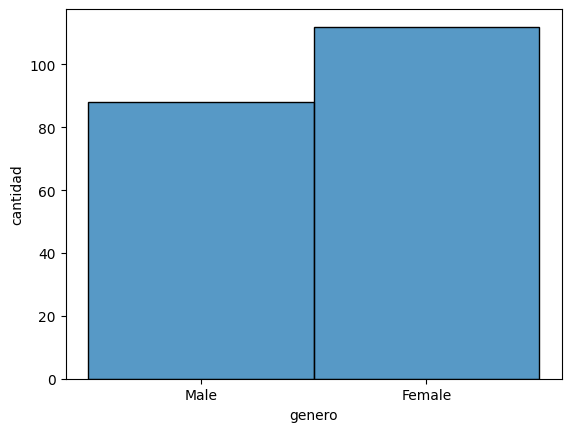

In [8]:
#mostrar comportamiento de varias variables para su compresnsion
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data= df, x="Genre")
plt.xlabel("genero")
plt.ylabel("cantidad")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

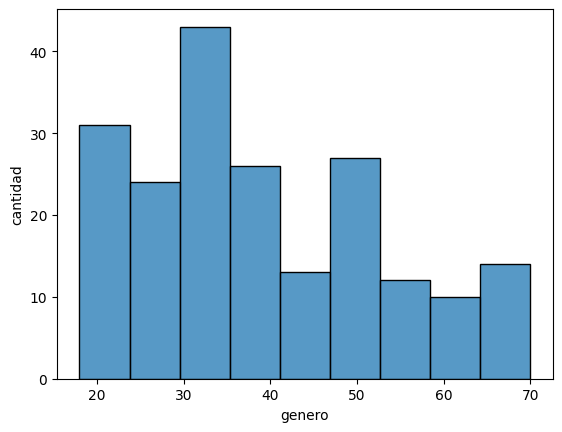

In [9]:
sns.histplot(data= df, x="Age")
plt.xlabel("genero")
plt.ylabel("cantidad")
plt.show

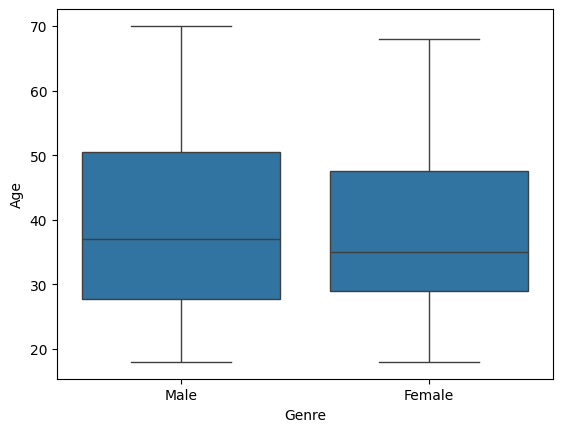

In [15]:
sns.boxplot(data=df,x="Genre",y="Age")
plt.show()

In [28]:
conteo = df.groupby("Genre").size()
conteo

Genre
Female    112
Male       88
dtype: int64

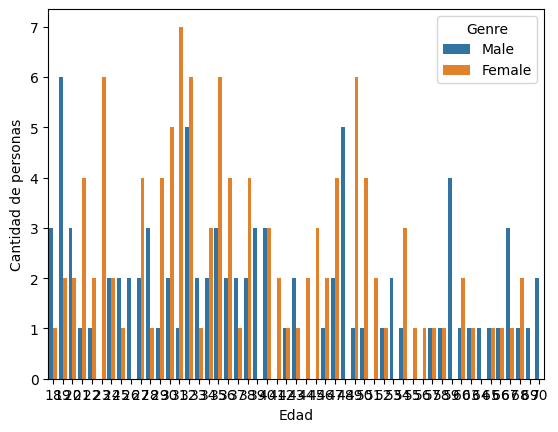

In [33]:
sns.countplot(data=df, x="Age", hue="Genre")

plt.xlabel("Edad")
plt.ylabel("Cantidad de personas")

plt.show()

In [7]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
#transformacion de datos con mixMax
df_numeric= df.select_dtypes(include="number")
df_minmax= MinMaxScaler()
df_minmax_escalado= df_minmax.fit_transform(df_numeric)
df_minmax_escalado

array([[0.        , 0.01923077, 0.        , 0.3877551 ],
       [0.00502513, 0.05769231, 0.        , 0.81632653],
       [0.01005025, 0.03846154, 0.00819672, 0.05102041],
       [0.01507538, 0.09615385, 0.00819672, 0.7755102 ],
       [0.0201005 , 0.25      , 0.01639344, 0.39795918],
       [0.02512563, 0.07692308, 0.01639344, 0.76530612],
       [0.03015075, 0.32692308, 0.02459016, 0.05102041],
       [0.03517588, 0.09615385, 0.02459016, 0.94897959],
       [0.04020101, 0.88461538, 0.03278689, 0.02040816],
       [0.04522613, 0.23076923, 0.03278689, 0.7244898 ],
       [0.05025126, 0.94230769, 0.03278689, 0.13265306],
       [0.05527638, 0.32692308, 0.03278689, 1.        ],
       [0.06030151, 0.76923077, 0.04098361, 0.14285714],
       [0.06532663, 0.11538462, 0.04098361, 0.7755102 ],
       [0.07035176, 0.36538462, 0.04098361, 0.12244898],
       [0.07537688, 0.07692308, 0.04098361, 0.79591837],
       [0.08040201, 0.32692308, 0.04918033, 0.34693878],
       [0.08542714, 0.03846154,

In [ ]:
#normalizacion con standerscaler
df_numeric= df.select_dtypes(include="number")
df_stander=StandardScaler()
df_stander_escalado= df_stander.fit_transform(df_numeric)
df_stander_escalado

array([[-1.7234121 , -1.42456879, -1.73899919, -0.43480148],
       [-1.70609137, -1.28103541, -1.73899919,  1.19570407],
       [-1.68877065, -1.3528021 , -1.70082976, -1.71591298],
       [-1.67144992, -1.13750203, -1.70082976,  1.04041783],
       [-1.6541292 , -0.56336851, -1.66266033, -0.39597992],
       [-1.63680847, -1.20926872, -1.66266033,  1.00159627],
       [-1.61948775, -0.27630176, -1.62449091, -1.71591298],
       [-1.60216702, -1.13750203, -1.62449091,  1.70038436],
       [-1.5848463 ,  1.80493225, -1.58632148, -1.83237767],
       [-1.56752558, -0.6351352 , -1.58632148,  0.84631002],
       [-1.55020485,  2.02023231, -1.58632148, -1.4053405 ],
       [-1.53288413, -0.27630176, -1.58632148,  1.89449216],
       [-1.5155634 ,  1.37433211, -1.54815205, -1.36651894],
       [-1.49824268, -1.06573534, -1.54815205,  1.04041783],
       [-1.48092195, -0.13276838, -1.54815205, -1.44416206],
       [-1.46360123, -1.20926872, -1.54815205,  1.11806095],
       [-1.4462805 , -0.

In [13]:
#correlacion de pearson
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [19]:
from scipy.stats import pearsonr
correlacion, _ = pearsonr(df["Age"],df["Annual Income (k$)"])
correlacion, _

(np.float64(-0.012398042736060159), np.float64(0.8616748930180228))

In [29]:
from scipy.stats import pearsonr
correlacion, _ = pearsonr(df["Annual Income (k$)"],df["Spending Score (1-100)"])
correlacion, _

(np.float64(0.009902848094037619), np.float64(0.8893134370273993))

<function matplotlib.pyplot.show(close=None, block=None)>

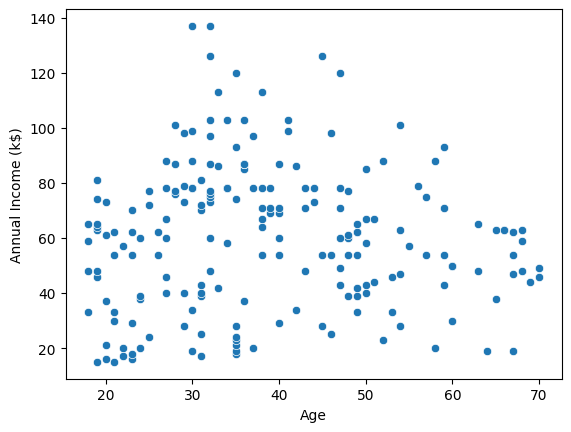

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x="Age",y="Annual Income (k$)")
plt.show

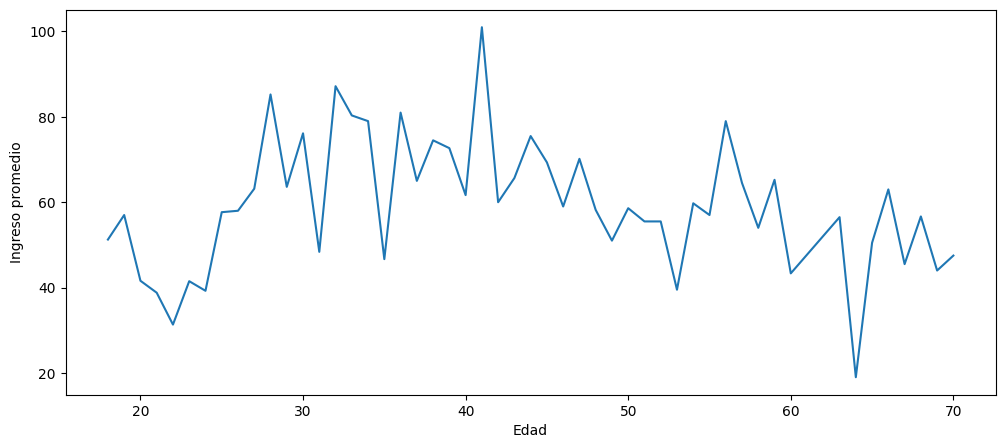

In [28]:
edad_ingreso = df.groupby("Age")["Annual Income (k$)"].mean()

plt.figure(figsize=(12,5))

plt.plot(
    edad_ingreso.index,
    edad_ingreso.values
)

plt.xlabel("Edad")
plt.ylabel("Ingreso promedio")

plt.show()